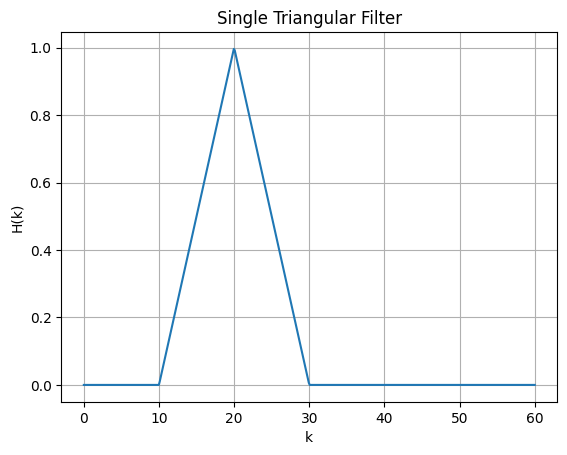

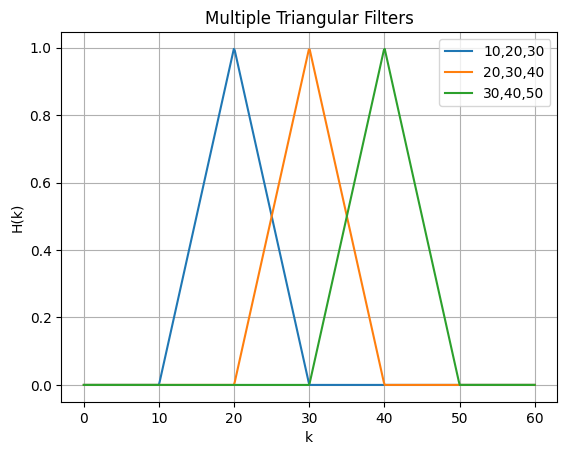

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def triangular_filter(k, a, b, c):
    H = np.zeros_like(k, dtype=float)

    for i in range(len(k)):
        if k[i] < a:
            H[i] = 0
        elif a <= k[i] <= b:
            H[i] = (k[i] - a) / (b - a)
        elif b <= k[i] <= c:
            H[i] = (c - k[i]) / (c - b)
        else:
            H[i] = 0
    return H

# k-axis
k = np.linspace(0, 60, 500)

# (i) Single triangle
a, b, c = 10, 20, 30
H = triangular_filter(k, a, b, c)

plt.plot(k, H)
plt.title("Single Triangular Filter")
plt.xlabel("k")
plt.ylabel("H(k)")
plt.grid()
plt.show()

# (ii) Multiple triangles
triangles = [(10,20,30), (20,30,40), (30,40,50)]

plt.figure()
for (a,b,c) in triangles:
    H = triangular_filter(k, a, b, c)
    plt.plot(k, H, label=f"{a},{b},{c}")

plt.title("Multiple Triangular Filters")
plt.xlabel("k")
plt.ylabel("H(k)")
plt.legend()
plt.grid()
plt.show()

In [ ]:
fs = 16000
N = 512
M = 20

In [ ]:
def hz_to_mel(f):
    return 2595 * np.log10(1 + f / 700)

def mel_to_hz(m):
    return 700 * (10**(m / 2595) - 1)

In [ ]:
f_min = 0
f_max = fs / 2

mel_min = hz_to_mel(f_min)
mel_max = hz_to_mel(f_max)

mel_points = np.linspace(mel_min, mel_max, M + 2)

In [ ]:
hz_points = mel_to_hz(mel_points)

In [ ]:
bins = np.floor((N + 1) * hz_points / fs).astype(int)

In [ ]:
filter_bank = np.zeros((M, int(N/2 + 1)))

for m in range(1, M + 1):
    f_m_minus = bins[m - 1]
    f_m = bins[m]
    f_m_plus = bins[m + 1]

    for k in range(f_m_minus, f_m):
        filter_bank[m-1, k] = (k - f_m_minus) / (f_m - f_m_minus)

    for k in range(f_m, f_m_plus):
        filter_bank[m-1, k] = (f_m_plus - k) / (f_m_plus - f_m)

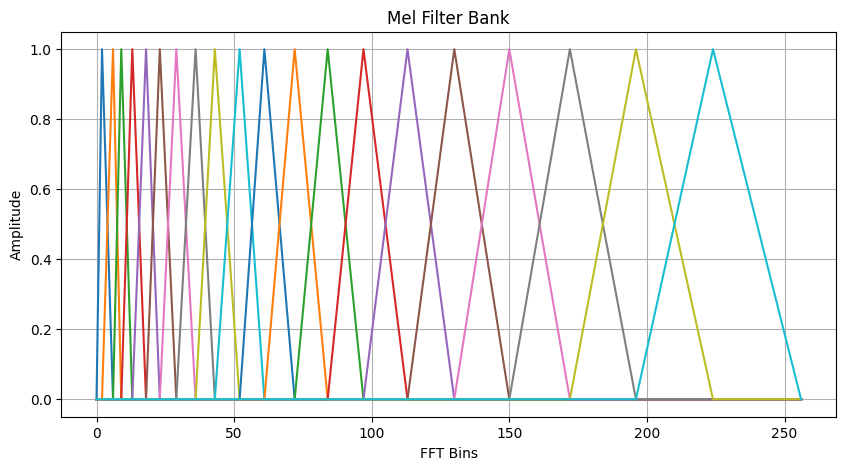

In [ ]:
plt.figure(figsize=(10,5))
for i in range(M):
    plt.plot(filter_bank[i])

plt.title("Mel Filter Bank")
plt.xlabel("FFT Bins")
plt.ylabel("Amplitude")
plt.grid()
plt.show()

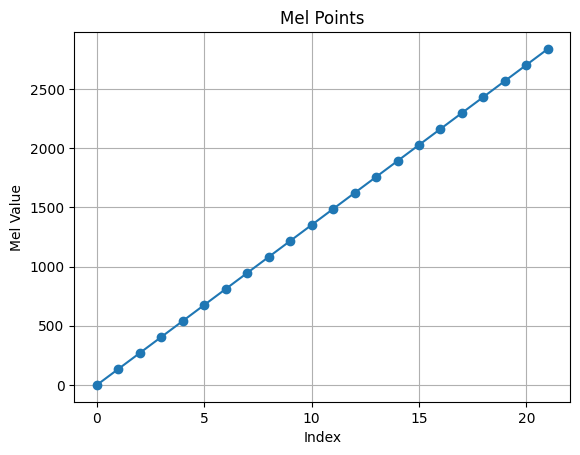

In [ ]:
plt.plot(mel_points, 'o-')
plt.title("Mel Points")
plt.xlabel("Index")
plt.ylabel("Mel Value")
plt.grid()
plt.show()

In [ ]:
for i in range(1, M+1):
    print(f"Filter {i}: a={bins[i-1]}, b={bins[i]}, c={bins[i+1]}")

Filter 1: a=0, b=2, c=6
Filter 2: a=2, b=6, c=9
Filter 3: a=6, b=9, c=13
Filter 4: a=9, b=13, c=18
Filter 5: a=13, b=18, c=23
Filter 6: a=18, b=23, c=29
Filter 7: a=23, b=29, c=36
Filter 8: a=29, b=36, c=43
Filter 9: a=36, b=43, c=52
Filter 10: a=43, b=52, c=61
Filter 11: a=52, b=61, c=72
Filter 12: a=61, b=72, c=84
Filter 13: a=72, b=84, c=97
Filter 14: a=84, b=97, c=113
Filter 15: a=97, b=113, c=130
Filter 16: a=113, b=130, c=150
Filter 17: a=130, b=150, c=172
Filter 18: a=150, b=172, c=196
Filter 19: a=172, b=196, c=224
Filter 20: a=196, b=224, c=256
